In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats


In [5]:
df=sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [6]:
df=df.dropna(subset=['age','fare'])

In [7]:
numerical_features=['age','fare']

In [8]:
#descriptive statitics
desc_sts=df[numerical_features].agg(['mean','median','std'])


In [9]:
skew=df[numerical_features].skew()
skew

age     0.389108
fare    4.653630
dtype: float64

In [10]:
kurtosis=df[numerical_features].kurtosis()
kurtosis

age      0.178274
fare    30.924249
dtype: float64

<Axes: xlabel='age', ylabel='Count'>

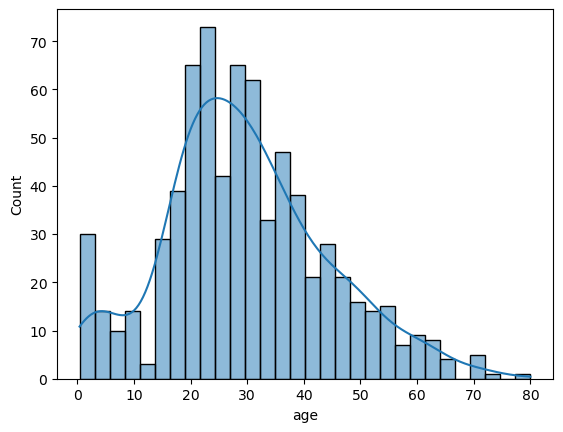

In [11]:
sns.histplot(df['age'],bins=30,kde=True)

<Axes: xlabel='survived', ylabel='fare'>

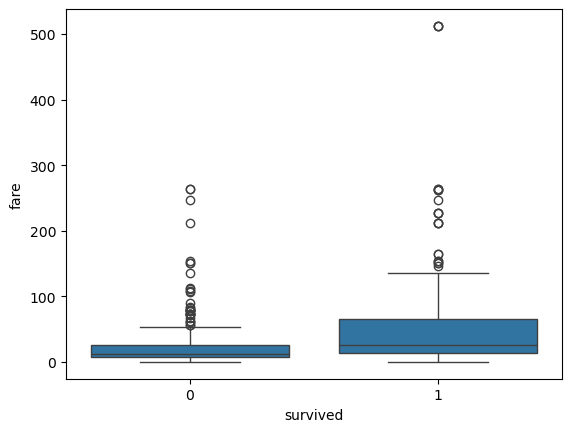

In [12]:
sns.boxplot(x=df['survived'],y=df['fare'])

In [13]:
survivors=df[df['survived']==1]['age']
not_survived=df[df['survived']==0]['age']
t_stat,p_value=stats.ttest_ind(survivors,not_survived,equal_var=False)
print(t_stat,p_value)

-2.0460301043939704 0.04118965162586639


In [26]:
#chi_square test
contingency=pd.crosstab(df['age'],df['sex'])
chi2,p,dof,extend=stats.chi2_contingency(contingency)
chi2

88.70451124242598

In [15]:
#confidence Interval
fare_survivors=df[df['survived']==1]['fare']
mean_fare=fare_survivors.mean()
std_fare=fare_survivors.std()
n=len(fare_survivors)
con_interval=stats.t.interval(0.95,df=n-1,loc=mean_fare,scale=std_fare/np.sqrt(n))

In [16]:
#logistic_Regression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report


In [17]:
df_model=df[['survived','age','sex','pclass']].dropna()

In [18]:
le=LabelEncoder()
df_model['sex']=le.fit_transform(df_model['sex'])

In [19]:
X=df_model[['age','sex','pclass']]
y=df_model['survived']


In [20]:
model=LogisticRegression()
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [21]:
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
y_pred

array([0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1])

In [22]:
#evaluate Model
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79        87
           1       0.67      0.70      0.68        56

    accuracy                           0.75       143
   macro avg       0.74      0.74      0.74       143
weighted avg       0.75      0.75      0.75       143



In [23]:
import statsmodels.api as sm 


In [24]:
x_const=sm.add_constant(X)
logit_model=sm.Logit(y,x_const)
result=logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.453285
         Iterations 6


In [25]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  714
Model:                          Logit   Df Residuals:                      710
Method:                           MLE   Df Model:                            3
Date:                Wed, 10 Sep 2025   Pseudo R-squ.:                  0.3289
Time:                        10:01:52   Log-Likelihood:                -323.65
converged:                       True   LL-Null:                       -482.26
Covariance Type:            nonrobust   LLR p-value:                 1.860e-68
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0560      0.502     10.069      0.000       4.072       6.040
age           -0.0369      0.008     -4.841      0.000      -0.052      -0.022
sex           -2.5221      0.207    -12.168      0.0